<a href="https://colab.research.google.com/github/Raphiyooo/machine-learning/blob/main/advertising_data_linear_regression_walkthrough.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [11]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [13]:
advertise_data = pd.read_csv('Advertising.csv')

In [14]:
advertise_data.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [15]:
advertise_data.drop(['Unnamed: 0'], axis=1, inplace=True)

In [16]:
advertise_data.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


# **1. Assign X and Y**


*   X: Predictor variables, what data do i have that helps me make a prediction
*   y: The data i have that should be predicted



In [17]:
X = advertise_data.drop(['sales'], axis=1)
y = advertise_data['sales']

## **Splitting the data**
usuallly the training set is around (70-80%) and the test set between (20-30%)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=70)

Here you could scale the data

# **Training the Model**
you give the model the training data and it gets fitted, then you can look up at the slope and intercept

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
print(model.intercept_)
print(model.coef_)

2.4887592567216554
[4.72663771e-02 1.93513062e-01 6.72342610e-05]


# **Test the Model**
give the X_test into the model and compare it with the actual values y_test

In [21]:
y_pred = model.predict(X_test)

# **Evaluate the Model**
Calculate all errors you want to check, you can also plot the results and compare the actual values and the predicted values

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [23]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'R-squared (R2): {r2:.2f}')

Mean Absolute Error (MAE): 1.26
Mean Squared Error (MSE): 2.56
R-squared (R2): 0.91


# **Plotting the model**

Below you see a scatterplot to visualize the performance, comparing the actual values (y_test) against the predicted values (y_pred)

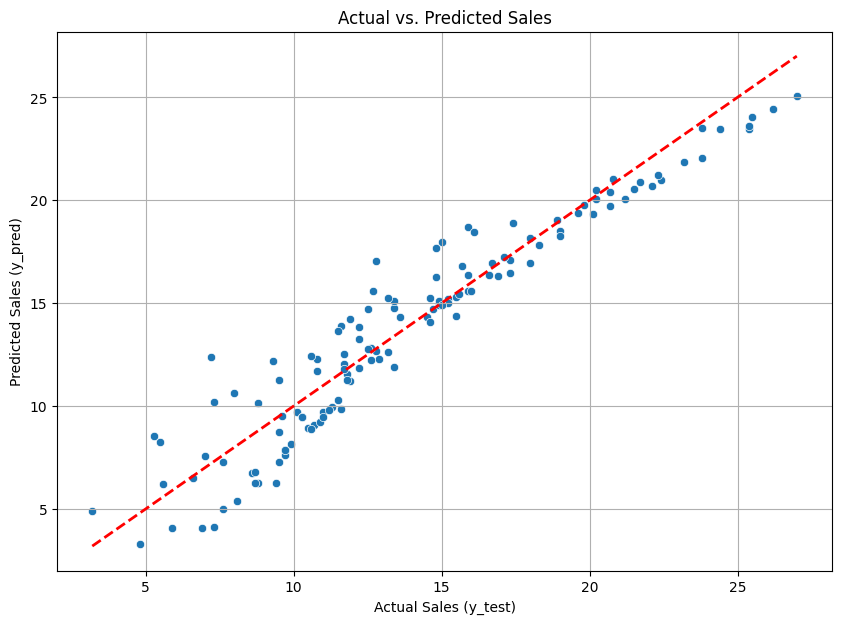

In [25]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales (y_test)')
plt.ylabel('Predicted Sales (y_pred)')
plt.title('Actual vs. Predicted Sales')
plt.grid(True)
plt.show()